Punto 1

<>:112: SyntaxWarning: invalid escape sequence '\s'
<>:112: SyntaxWarning: invalid escape sequence '\s'
/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_99435/1804176213.py:112: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Roughness RMS $\sigma$')


Simulation completed
Escape time
<τ> - 1/ktot =  8.70661448429985e-06
Plots


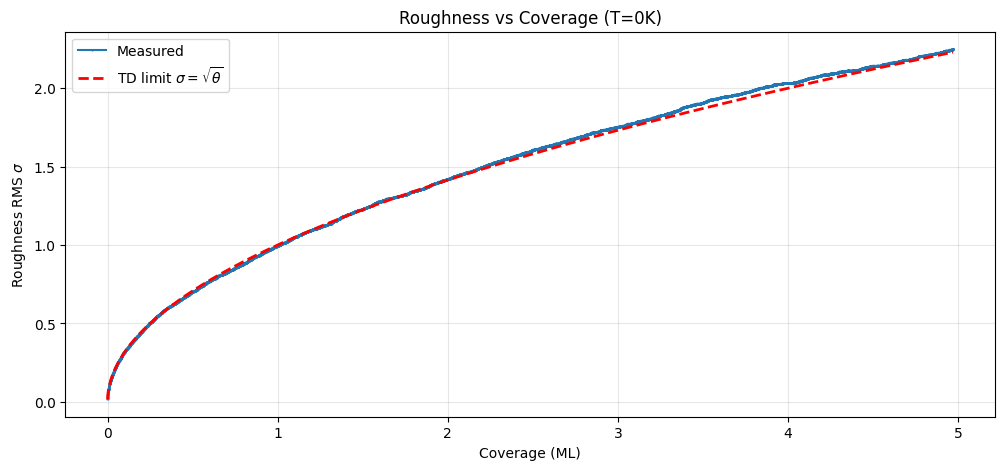

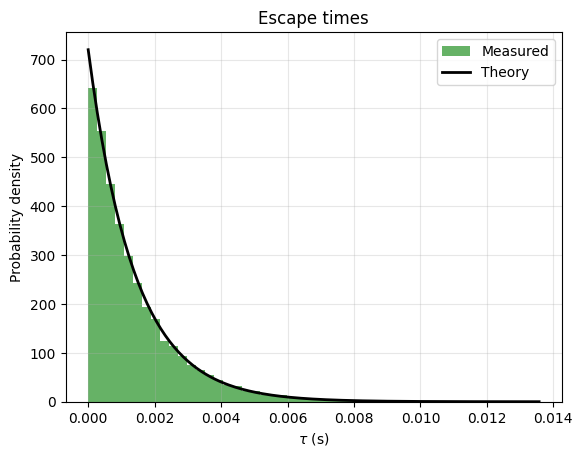

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from KMC_codes import printXYZ
import os


#input and parameters
myseed=16324478
np.random.seed(myseed)
k_B = 1 / 11603
Lx = 60     
Ly = 60    
L = 60 
flux = 0.2
cov_nom = 5
Temp = 0
nu = 1*10**(13)
J1 = -0.345
J0 = 4 * J1

#initializations
height = np.zeros((Lx,Ly),int) 
Ndep = 0
time = 0
outputTime = 0
endtime = cov_nom / flux
dtSnap = 0.1 / flux
nfile = 0
list_tau = []       
list_cov = []
list_sigma = [] 
kdif = np.zeros((Lx,Ly))
kdepo = flux * Lx * Ly


BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_KMC_1.ipynb'))
results_dir1 = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 1', 'Finali')
os.makedirs(results_dir1, exist_ok=True)
base_filename0 = f'KMC_xyz_depo_{str(Temp)}K_Flux_{flux}_L_{L}_SNAP_0.xyz'
outputname0 = os.path.join(results_dir1, base_filename0)
printXYZ(outputname0, height, Lx, Ly)


#MC loop
while time < endtime:

    #compute rates
    ktot = kdepo

    #extract first escape
    r = np.random.rand()
    tau = -np.log(r) / ktot
    list_tau.append(tau)

    #output (when needed)
    if (time >= outputTime):
        
        base_filename1 = f'KMC_xyz_depo_{str(Temp)}K_Flux_{flux}_L_{L}_SNAP_{str(nfile+1)}.xyz'
        outputname1 = os.path.join(results_dir1, base_filename1)
        printXYZ(outputname1, height, Lx, Ly)

        outputTime += dtSnap       #next snapshot  
        nfile += 1                 #progressive file number 

     
    #select event
    #implement event
    xdepo = np.random.randint(Lx)
    ydepo = np.random.randint(Ly)
    height[xdepo,ydepo] += 1
    Ndep +=1 

    cov_real = Ndep / (Lx*Ly)
    list_cov.append(cov_real)
    sigma2_teo = cov_real * (1 - 1/(Lx*Ly)) 
    sigma_teo = np.sqrt(sigma2_teo)
    sigma = np.std(height)
    list_sigma.append(sigma)

    

    #increment time to next timestep
    time += tau

#salva liste in file separato
namefdir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 1', 'flux comparison', 'lists')
namef = os.path.join(namefdir, f"KMC_lists_depo_Temp_{Temp}_Flux_{flux}_L_{L}.txt")
os.makedirs(namefdir, exist_ok=True)
fout_lists = open(namef, 'w')
fout_lists.write(f"{list_cov} {list_sigma} {list_tau}\n")
fout_lists.close()





print("Simulation completed")
print("Escape time")
tau_ave = np.mean(np.array(list_tau))
print("<τ> - 1/ktot = ", tau_ave - 1/ktot)

# --- PLOT ---
print("Plots")
plt.figure(figsize=(12, 5))

# GRAFICO 1: Rugosità vs Copertura
# Dati simulati (misurati dalla matrice height)
plt.plot(list_cov, list_sigma, 'o-', markersize=0.5, label='Measured')
# Curva Teorica 
plt.plot(list_cov, np.sqrt(list_cov), 'r--', linewidth=2, label=r'TD limit $\sigma=\sqrt{\theta}$')
plt.xlabel('Coverage (ML)')
plt.ylabel('Roughness RMS $\sigma$')
plt.title(f'Roughness vs Coverage (T={str(Temp)}K)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# GRAFICO 2: Distribuzione dei tempi tau
# Istogramma dei tau raccolti
count, bins, ignored = plt.hist(list_tau, bins=50, density=True, alpha=0.6, color='green', label='Measured')
# Curva Teorica  
x_vals = np.linspace(0, max(bins), 200)
y_vals = ktot * np.exp(-ktot * x_vals)
plt.plot(x_vals, y_vals, 'k-', linewidth=2, label='Theory')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel('Probability density')
plt.title('Escape times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Punto 2

Ciclo sui flussi

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from KMC_codes import printXYZ, pbcCorr, findMove, get_neighborhood, get_rate_at
import os
import time

# --- SETUP CARTELLE ---
BASE_PATH = os.getcwd() # Usa la directory corrente
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 2', 'flux comparison')
os.makedirs(results_dir, exist_ok=True)

# --- PARAMETRI FISI ---
myseed = 16324478
np.random.seed(myseed)
k_B = 1 / 11603
Lx = 60     
Ly = 60 
L = 60
cov_nom = 5
Temp = 770     # Alta temperatura
nu = 1e13
J1 = -0.345    # eV
J0 = 4 * J1

# Lista dei flussi da simulare
#flux_list = [10, 1, 0.1, 0.01, 0.0001]
flux_list = [1]

# Dizionario per salvare i risultati di ogni run
# Struttura: { valore_flux : (lista_cov, lista_sigma) }
results_db = {}

# --- CICLO SUI FLUSSI ---
for flux in flux_list:
    print(f"\n{'='*40}")
    print(f"AVVIO SIMULAZIONE CON FLUX = {flux} ML/s")
    print(f"{'='*40}")

    # --- INIZIALIZZAZIONI (RESET PER OGNI FLUSSO) ---
    height = np.zeros((Lx,Ly), int) 
    Ndep = 0
    Time = 0
    outputTime = 0
    
    # Parametri dipendenti dal flusso
    endtime = cov_nom / flux
    dtSnap = 0.1 / flux  # Snapshot ogni 0.1 ML (indipendente dal tempo assoluto)
    kdepo = flux * Lx * Ly
    
    nfile = 0
    list_cov = []
    list_sigma = [] 
    list_tau = []
    
    # Inizializzazione Rates
    kdif = np.zeros((Lx,Ly))
    print("Inizializzazione rates...")
    for i in range(Lx):
        for j in range(Ly):
            kdif[i,j] = get_rate_at(i, j, height, Temp, L, J0, J1)

    ktot = kdepo + np.sum(kdif)
    
    fname = os.path.join(results_dir, f'KMC_xyz_diff_Temp_{Temp}_Flux_{flux}_L_{L}_Snap_{nfile}.xyz')
    printXYZ(fname, height, Lx, Ly)
    
    # --- MC LOOP ---
    stepcount = 0
    while Time < endtime:

        # 1. Avanzamento Tempo
        if ktot <= 1e-20: ktot = 1e-20
        r = np.random.rand()
        if r == 0: r = 1e-10
        tau = -np.log(r) / ktot
        
        #substrato piano
        if Time == 0:
            fname = os.path.join(results_dir, f'KMC_xyz_diff_Temp_{Temp}_Flux_{flux}_L_{L}_Snap_{nfile}.xyz')
            printXYZ(fname, height, Lx, Ly)

        Time += tau
        list_tau.append(tau)
        stepcount += 1


        # Calcolo osservabili
        cov_curr = Ndep / (Lx*Ly)
        sigma_curr = np.std(height)
        
        # Salvataggio in liste
        list_cov.append(cov_curr)
        list_sigma.append(sigma_curr)
        
        # 2. Output & Campionamento Dati
        if (Time > outputTime):
            
            # Stampa progresso (utile per debug)
            print(f"  Flux {flux} | Cov {cov_curr:.2f} | Sigma {sigma_curr:.2f}")
            
            # (Opzionale) Output XYZ
            fname = os.path.join(results_dir, f'KMC_xyz_diff_Temp_{Temp}_Flux_{flux}_L_{L}_Snap_{nfile}.xyz')
            printXYZ(fname, height, Lx, Ly)

            outputTime += dtSnap
            nfile += 1
            

        # 3. Selezione Evento
        rho = ktot * np.random.rand()

        if rho < kdepo:
            # --- DEPOSIZIONE ---
            x = np.random.randint(Lx)
            y = np.random.randint(Ly)
            
            affected_sites = get_neighborhood(x, y, Lx, Ly)
            
            for (ix, iy) in affected_sites:
                ktot -= kdif[ix, iy]

            height[x, y] += 1
            Ndep += 1 

            for (ix, iy) in affected_sites:
                new_k = get_rate_at(ix, iy, height, Temp, L, J0, J1)
                kdif[ix, iy] = new_k
                ktot += new_k
            
        else:
            # --- DIFFUSIONE ---
            rho_diff = rho - kdepo
            # Nota: usa la tua findMove o np.searchsorted
            xo, yo = findMove(rho_diff, kdif, L)
            
            dir_rand = np.random.rand()
            if dir_rand < 0.25:   
                xD, yD = pbcCorr(xo-1, Lx), yo
            elif dir_rand < 0.5:  
                xD, yD = pbcCorr(xo+1, Lx), yo
            elif dir_rand < 0.75: 
                xD, yD = xo, pbcCorr(yo+1, Ly)
            else:                 
                xD, yD = xo, pbcCorr(yo-1, Ly)
            
            if height[xo, yo] > 0:
                affected_start = get_neighborhood(xo, yo, Lx, Ly)
                affected_end = get_neighborhood(xD, yD, Lx, Ly)
                affected_sites = affected_start | affected_end # Unione insiemi
            
                for (ix, iy) in affected_sites:
                    ktot -= kdif[ix, iy]
            
                height[xo, yo] -= 1
                height[xD, yD] += 1

                for (ix, iy) in affected_sites:
                    new_k = get_rate_at(ix, iy, height, Temp, L, J0, J1)
                    kdif[ix, iy] = new_k
                    ktot += new_k

    # Salvataggio risultati nel dizionario globale
    results_db[flux] = (list_cov, list_sigma)
    print(f"Simulazione Flux {flux} completata.")

    #salva liste in file separato
    namefpath = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 2', 'flux comparison')
    namef = os.path.join(namefpath, f"KMC_lists_diff_Temp_{Temp}_Flux_{flux}_L_{L}.txt")
    fout_lists = open(namef, 'w')
    fout_lists.write(f"{list_cov} {list_sigma} {list_tau}\n")
    fout_lists.close()

# --- PLOT COMPARATIVO FINALE ---
print("\nGenerazione Grafico Comparativo...")
plt.figure(figsize=(10, 6))
colors = ['blue', 'cyan', 'orange', 'green', 'purple'] # Colori per i diversi flussi
#curva sperimentale
for i, flux in enumerate(flux_list):
    cov_data, sigma_data = results_db[flux]
    col = colors[i % len(colors)]
    plt.plot(cov_data, sigma_data, 'o-', markersize=1.0 , color=col, label=f'Flux = {flux} ML/s')

# Curva Teorica Random Deposition (limite superiore)
# Usiamo i dati dell'ultimo flusso per l'asse x teorico
x_theory = np.array(cov_data)
plt.plot(x_theory, np.sqrt(x_theory), 'k--', linewidth=2, label=r'Random Dep. ($\sigma=\sqrt{\theta}$)')

plt.xlabel('Coverage (ML)')
plt.ylabel(r'Roughness (RMS) $\sigma$')
plt.title(f'Roughness vs Flux (T={Temp} K)')
plt.legend()
plt.grid(True, alpha=0.3)

output_plot1 = os.path.join(results_dir, 'Confronto_Flux.png')
plt.savefig(output_plot1)
plt.show()

# GRAFICO 2: Distribuzione dei tempi tau
# Istogramma dei tau raccolti
count, bins, ignored = plt.hist(list_tau, bins=100, density=True, alpha=0.6, color='green', label='Measured')
# Curva Teorica  
x_vals = np.linspace(0, max(bins), 200)
y_vals = ktot * np.exp(-ktot * x_vals)
plt.plot(x_vals, y_vals, 'k-', linewidth=2, label='Theory')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel('Probability density')
plt.title('Escape times')
plt.legend()
plt.grid(True, alpha=0.3)
output_plot2 = os.path.join(results_dir, 'Confronto_Tau.png')
plt.savefig(output_plot2)
plt.show()

Punto 2 senza ciclo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from KMC_codes import printXYZ, pbcCorr, findMove, get_neighborhood, get_rate_at
import os
import time

# --- SETUP CARTELLE ---
BASE_PATH = os.getcwd() # Usa la directory corrente
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 2', 'Singole simulazioni')
os.makedirs(results_dir, exist_ok=True)

# --- PARAMETRI FISI ---
myseed = 16324478
np.random.seed(myseed)
k_B = 1 / 11603
Lx = 60     
Ly = 60 
L = 60
cov_nom = 5
Temp = 650   # Alta temperatura
nu = 1e13
flux = 0.01
J1 = -0.345    # eV
J0 = 4 * J1

# Dizionario per salvare i risultati di ogni run
# Struttura: { valore_flux : (lista_cov, lista_sigma) }
results_db = {}

# --- CICLO SUI FLUSSI ---

print(f"\n{'='*40}")
print(f"AVVIO SIMULAZIONE CON FLUX = {flux} ML/s")
print(f"{'='*40}")

# --- INIZIALIZZAZIONI (RESET PER OGNI FLUSSO) ---
height = np.zeros((Lx,Ly), int) 
Ndep = 0
Time = 0
outputTime = 0

# Parametri dipendenti dal flusso
endtime = cov_nom / flux
dtSnap = 0.1 / flux  # Snapshot ogni 0.1 ML (indipendente dal tempo assoluto)
kdepo = flux * Lx * Ly

nfile = 0
list_cov = []
list_sigma = [] 
list_tau = []

# Inizializzazione Rates
kdif = np.zeros((Lx,Ly))
print("Inizializzazione rates...")
for i in range(Lx):
    for j in range(Ly):
        kdif[i,j] = get_rate_at(i, j, height, Temp, L, J0, J1)

ktot = kdepo + np.sum(kdif)

# --- MC LOOP ---
stepcount = 0
while Time < endtime:

    # 1. Avanzamento Tempo
    if ktot <= 1e-20: ktot = 1e-20
    r = np.random.rand()
    if r == 0: r = 1e-10
    tau = -np.log(r) / ktot
    
    Time += tau
    list_tau.append(tau)
    stepcount += 1


    # Calcolo osservabili
    cov_curr = Ndep / (Lx*Ly)
    sigma_curr = np.std(height)
    
    # Salvataggio in liste
    list_cov.append(cov_curr)
    list_sigma.append(sigma_curr)
    
    # 2. Output & Campionamento Dati
    if Time > outputTime:
        
        # Stampa progresso (utile per debug)
        print(f"  Flux {flux} | Cov {cov_curr:.2f} | Sigma {sigma_curr:.2f}")
        
        # (Opzionale) Output XYZ
        fname = os.path.join(results_dir, f'KMC_xyz_diff_Temp_{Temp}_Flux_{flux}_L_{L}_Snap_{nfile}.xyz')
        printXYZ(fname, height, Lx, Ly)

        outputTime += dtSnap
        nfile += 1
        

    # 3. Selezione Evento
    rho = ktot * np.random.rand()

    if rho < kdepo:
        # --- DEPOSIZIONE ---
        x = np.random.randint(Lx)
        y = np.random.randint(Ly)
        
        affected_sites = get_neighborhood(x, y, Lx, Ly)
        
        for (ix, iy) in affected_sites:
            ktot -= kdif[ix, iy]

        height[x, y] += 1
        Ndep += 1 

        for (ix, iy) in affected_sites:
            new_k = get_rate_at(ix, iy, height, Temp, L, J0, J1)
            kdif[ix, iy] = new_k
            ktot += new_k
        
    else:
        # --- DIFFUSIONE ---
        rho_diff = rho - kdepo
        # Nota: usa la tua findMove o np.searchsorted
        xo, yo = findMove(rho_diff, kdif, L)
        
        dir_rand = np.random.rand()
        if dir_rand < 0.25:#left
            xD, yD = pbcCorr(xo-1, Lx), yo
        elif dir_rand < 0.5:#right  
            xD, yD = pbcCorr(xo+1, Lx), yo
        elif dir_rand < 0.75:#up 
            xD, yD = xo, pbcCorr(yo+1, Ly)
        else:               #down  
            xD, yD = xo, pbcCorr(yo-1, Ly)
        
        if height[xo, yo] > 0:
            affected_start = get_neighborhood(xo, yo, Lx, Ly)
            affected_end = get_neighborhood(xD, yD, Lx, Ly)
            affected_sites = affected_start | affected_end # Unione insiemi
        
            for (ix, iy) in affected_sites:
                ktot -= kdif[ix, iy]
        
            height[xo, yo] -= 1
            height[xD, yD] += 1

            for (ix, iy) in affected_sites:
                new_k = get_rate_at(ix, iy, height, Temp, L, J0, J1)
                kdif[ix, iy] = new_k
                ktot += new_k

# Salvataggio risultati nel dizionario globale
results_db[flux] = (list_cov, list_sigma)
print(f"Simulazione Flux {flux} completata.")

#salva liste in file separato
namef = os.path.join(results_dir, f"KMC_lists_diff_Temp_{Temp}_Flux_{flux}_L_{L}.txt")
fout_lists = open(namef, 'w')
fout_lists.write(f"{list_cov} {list_sigma} {list_tau}\n")
fout_lists.close()

# --- PLOT COMPARATIVO FINALE ---
print("\nGenerazione Grafico Comparativo...")
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'orange'] # Colori per i diversi flussi
#curva sperimentale
cov_data, sigma_data = results_db[flux]
plt.plot(cov_data, sigma_data, 'o-', markersize=1.0 , label=f'Flux = {flux} ML/s')

# Curva Teorica Random Deposition (limite superiore)
# Usiamo i dati dell'ultimo flusso per l'asse x teorico
x_theory = np.array(cov_data)
plt.plot(x_theory, np.sqrt(x_theory), 'k--', linewidth=2, label=r'Random Dep. ($\sigma=\sqrt{\theta}$)')

plt.xlabel('Coverage (ML)')
plt.ylabel('Roughness (RMS) $\sigma$')
plt.title(f'Roughness vs Flux (T={Temp} K)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

'''# GRAFICO 2: Distribuzione dei tempi tau
# Istogramma dei tau raccolti
count, bins, ignored = plt.hist(list_tau, bins=100, density=True, alpha=0.6, color='green', label='Measured')
# Curva Teorica  
x_vals = np.linspace(0, max(bins), 200)
y_vals = ktot * np.exp(-ktot * x_vals)
plt.plot(x_vals, y_vals, 'k-', linewidth=2, label='Theory')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel('Probability density')
plt.title('Escape times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()'''

Plot 2 configurazioni a diversa temperatura e flusso


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Parametri ---
Temp1 = 650
Temp2 = 770
flux1 = 0.01
flux2 = 1.0
L = 60

BASE_PATH = os.getcwd()
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 2', 'Singole simulazioni')

namef1 = os.path.join(results_dir, f"KMC_lists_diff_Temp_{Temp1}_Flux_{flux1}_L_{L}.txt")
namef2 = os.path.join(results_dir, f"KMC_lists_diff_Temp_{Temp2}_Flux_{flux2}_L_{L}.txt")

def parse_lists_from_file(filepath):
    if not os.path.exists(filepath):
        print(f"ATTENZIONE: Il file {filepath} non esiste.")
        return np.array([]), np.array([]), np.array([])

    with open(filepath, 'r') as f:
        content = f.read().strip()
    
    # --- FIX CRUCIALE ---
    # Rimuoviamo la dicitura 'np.float64(' e la parentesi ')' che avvolgono i numeri
    content = content.replace('np.float64(', '').replace(')', '')
    # --------------------

    # Separiamo le tre liste cercando la chiusura e l'apertura delle quadre
    parts = content.split('] [')
    
    processed_arrays = []
    for p in parts:
        # Puliamo la stringa: togliamo le parentesi quadre residue
        clean_p = p.replace('[', '').replace(']', '')
        
        # Dividiamo per virgola (i tuoi file hanno le virgole)
        if ',' in clean_p:
            raw_values = clean_p.split(',')
        else:
            raw_values = clean_p.split()
            
        numeric_values = []
        for x in raw_values:
            x_strip = x.strip()
            if x_strip:
                try:
                    # Ora x_strip è un numero pulito (es: "1.23e-5"), float() funzionerà
                    val = float(x_strip)
                    numeric_values.append(val)
                except ValueError:
                    # Se fallisce ancora, stampiamo cosa sta fallendo per debug
                    # print(f"Fallita conversione di: {x_strip}") 
                    numeric_values.append(np.nan)
        
        processed_arrays.append(np.array(numeric_values))

    # Restituiamo le 3 liste (cov, sigma, tau)
    if len(processed_arrays) >= 2: # Accettiamo anche se manca tau, basta cov e sigma
        # Restituisce cov, sigma e (se c'è) tau, altrimenti array vuoto
        tau = processed_arrays[2] if len(processed_arrays) > 2 else np.array([])
        return processed_arrays[0], processed_arrays[1], tau
    else:
        print(f"Errore: Trovate {len(processed_arrays)} liste invece di 3 in {filepath}")
        return np.array([]), np.array([]), np.array([])

# --- Caricamento ---
print("Caricamento file 1...")
cov_data1, sigma_data1, _ = parse_lists_from_file(namef1)
print(f" -> Punti validi trovati: {np.count_nonzero(~np.isnan(cov_data1))}")

print("Caricamento file 2...")
cov_data2, sigma_data2, _ = parse_lists_from_file(namef2)
print(f" -> Punti validi trovati: {np.count_nonzero(~np.isnan(cov_data2))}")


# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# Plot Simulazione 1
if len(cov_data1) > 0:
    # Filtro eventuali NaN residui per evitare buchi nel plot
    mask1 = ~np.isnan(cov_data1) & ~np.isnan(sigma_data1)
    plt.plot(cov_data1[mask1], sigma_data1[mask1], 'o-', markersize=2.0, color='b', 
             label=f'Flux = {flux1} ML/s, T={Temp1}K')

# Plot Simulazione 2
if len(cov_data2) > 0:
    mask2 = ~np.isnan(cov_data2) & ~np.isnan(sigma_data2)
    plt.plot(cov_data2[mask2], sigma_data2[mask2], 'o-', markersize=2.0, color='r', 
             label=f'Flux = {flux2} ML/s, T={Temp2}K')

# Curva Teorica (Random Deposition)
# Usiamo il massimo range disponibile dai dati reali
max_cov = 0
if len(cov_data1) > 0: max_cov = max(max_cov, np.nanmax(cov_data1))
if len(cov_data2) > 0: max_cov = max(max_cov, np.nanmax(cov_data2))

if max_cov > 0:
    x_theory = np.linspace(0, max_cov, 100)
    plt.plot(x_theory, np.sqrt(x_theory), 'k--', linewidth=2, 
             label=r'Random Dep. ($\sigma=\sqrt{\theta}$)')

plt.xlabel('Coverage (ML)')
plt.ylabel(r'Roughness (RMS) $\sigma$')
plt.title(f'Roughness vs Flux comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Caricamento file 1...
 -> Punti validi trovati: 662735
Caricamento file 2...
 -> Punti validi trovati: 35536
Caricamento file 2...
 -> Punti validi trovati: 72304
Caricamento file 2...
 -> Punti validi trovati: 200246
Caricamento file 2...
 -> Punti validi trovati: 682816
Caricamento file 2...
 -> Punti validi trovati: 10616419


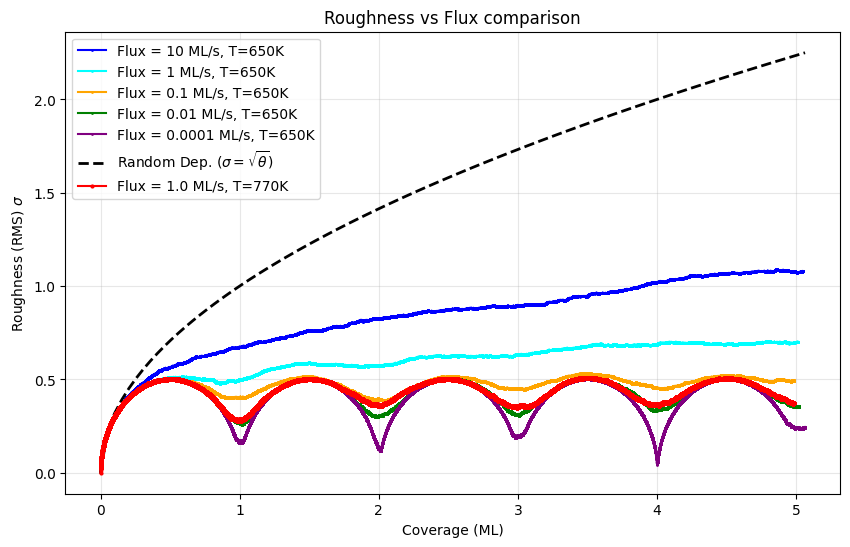

In [156]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Parametri ---
Temp1 = 770
Temp2 = 650
flux1 = 1.0
flux2 = 0.01
flux_list = [10, 1, 0.1, 0.01, 0.0001]
L = 60

BASE_PATH = os.getcwd()
results_dir1 = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 2', 'Singole simulazioni')
results_dir2 = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 2', 'flux comparison')
namef1 = os.path.join(results_dir1, f"KMC_lists_diff_Temp_{Temp1}_Flux_{flux1}_L_{L}.txt")

def parse_lists_from_file(filepath):
    if not os.path.exists(filepath):
        print(f"ATTENZIONE: Il file {filepath} non esiste.")
        return np.array([]), np.array([]), np.array([])

    with open(filepath, 'r') as f:
        content = f.read().strip()
    
    # --- FIX CRUCIALE ---
    # Rimuoviamo la dicitura 'np.float64(' e la parentesi ')' che avvolgono i numeri
    content = content.replace('np.float64(', '').replace(')', '')
    # --------------------

    # Separiamo le tre liste cercando la chiusura e l'apertura delle quadre
    parts = content.split('] [')
    
    processed_arrays = []
    for p in parts:
        # Puliamo la stringa: togliamo le parentesi quadre residue
        clean_p = p.replace('[', '').replace(']', '')
        
        # Dividiamo per virgola (i tuoi file hanno le virgole)
        if ',' in clean_p:
            raw_values = clean_p.split(',')
        else:
            raw_values = clean_p.split()
            
        numeric_values = []
        for x in raw_values:
            x_strip = x.strip()
            if x_strip:
                try:
                    # Ora x_strip è un numero pulito (es: "1.23e-5"), float() funzionerà
                    val = float(x_strip)
                    numeric_values.append(val)
                except ValueError:
                    # Se fallisce ancora, stampiamo cosa sta fallendo per debug
                    # print(f"Fallita conversione di: {x_strip}") 
                    numeric_values.append(np.nan)
        
        processed_arrays.append(np.array(numeric_values))

    # Restituiamo le 3 liste (cov, sigma, tau)
    if len(processed_arrays) >= 2: # Accettiamo anche se manca tau, basta cov e sigma
        # Restituisce cov, sigma e (se c'è) tau, altrimenti array vuoto
        tau = processed_arrays[2] if len(processed_arrays) > 2 else np.array([])
        return processed_arrays[0], processed_arrays[1], tau
    else:
        print(f"Errore: Trovate {len(processed_arrays)} liste invece di 3 in {filepath}")
        return np.array([]), np.array([]), np.array([])

# --- Caricamento ---
print("Caricamento file 1...")
cov_data1, sigma_data1, _ = parse_lists_from_file(namef1)
print(f" -> Punti validi trovati: {np.count_nonzero(~np.isnan(cov_data1))}")
plt.figure(figsize=(10, 6))
i = 0
for flux2 in flux_list:
    

    namef2 = os.path.join(results_dir2, f"KMC_lists_diff_Temp_{Temp2}_Flux_{flux2}_L_{L}.txt")

    print("Caricamento file 2...")
    cov_data2, sigma_data2, _ = parse_lists_from_file(namef2)
    print(f" -> Punti validi trovati: {np.count_nonzero(~np.isnan(cov_data2))}")


    # Plot Simulazione 2
    #curva sperimentale
    colors = ['blue', 'cyan', 'orange', 'green', 'purple'] # Colori per i diversi flussi
    col = colors[i]
    plt.subplot()
    if len(cov_data2) > 0:
        mask2 = ~np.isnan(cov_data2) & ~np.isnan(sigma_data2)
        plt.plot(cov_data2[mask2], sigma_data2[mask2], 'o-', markersize=1.0, color=col, 
                label=f'Flux = {flux2} ML/s, T={Temp2}K')
    i += 1
    

# Curva Teorica (Random Deposition)
# Usiamo il massimo range disponibile dai dati reali
max_cov = 0
if len(cov_data1) > 0: max_cov = max(max_cov, np.nanmax(cov_data1))
if len(cov_data2) > 0: max_cov = max(max_cov, np.nanmax(cov_data2))

if max_cov > 0:
    x_theory = np.linspace(0, max_cov, 100)
    plt.plot(x_theory, np.sqrt(x_theory), 'k--', linewidth=2, 
            label=r'Random Dep. ($\sigma=\sqrt{\theta}$)')



# Plot Simulazione 1
if len(cov_data1) > 0:
    # Filtro eventuali NaN residui per evitare buchi nel plot
    mask1 = ~np.isnan(cov_data1) & ~np.isnan(sigma_data1)
    plt.plot(cov_data1[mask1], sigma_data1[mask1], 'o-', markersize=2.0, color='r', 
             label=f'Flux = {flux1} ML/s, T={Temp1}K')

plt.xlabel('Coverage (ML)')
plt.ylabel(r'Roughness (RMS) $\sigma$')
plt.title(f'Roughness vs Flux comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Punto 3

Ciclo su natoms

In [127]:
import numpy as np
import matplotlib.pyplot as plt 
import os
import time
from numba import jit
from MMC_codes import energy, printXYZ, neighXYZ, pbcCorr
#folder
BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 3', 'natoms_list')
#os.makedirs(results_dir1, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

#input and parameters
#myseed=16324478
#myseed = 42
#myseed = 0
#myseed = 1
#myseed = 2026
myseed = 1926
np.random.seed(myseed)
k_B = 1 / 11603
Lx = 60     
Ly = 60 
L = 60
Temp = 0
nu = 1e13
J1 = -0.345
J0 = 4 * J1
#natoms_list = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
natoms_list = [21,22,23,24,25]
MCsteps = 1000000

for katoms in natoms_list:

    natoms = katoms
    print(f"Simulation using natoms = ", natoms)
    #initializations
    height = np.zeros((Lx,Ly),int) 
    istep = 0

    #initial configuration
    for iatoms in range(0,natoms):
        xin = np.random.randint(Lx)
        yin = np.random.randint(Lx)
        height[xin,yin] +=1
    print(np.sum(height)) #this should return natoms

    Eold = energy(height,Lx,Ly,J0,J1) #this should return a value around natoms*J0
    print(f"Initial energy E = ", Eold)
    print("natoms*J0: ", natoms*J0)
    print("Ein - natoms*J0: ", Eold - natoms*J0)



    base_filename2 = "MMC_energy_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+").txt"
    outputname2 = os.path.join(results_dir, base_filename2)
    fout = open(outputname2 , 'w')
    for istep in range(MCsteps):

        listAt = np.argwhere(height>0) 
        idxAt = np.random.randint(len(listAt)) 
        xold,yold = listAt[idxAt]
        height[xold,yold] -= 1

        xnew = np.random.randint(Lx)
        ynew = np.random.randint(Ly)
        height[xnew,ynew] += 1

        Enew = energy(height,Lx,Ly,J0,J1)

        #the new configuration becomes the current state
        if (Enew-Eold) < 1e-8: #the minimum difference is one bond (0.34 (?)) so we're safe
            Eold = Enew
        
            
        else: #restore previous configuration
            height[xold,yold] += 1
            height[xnew,ynew] -= 1                       

        #Output (when needed)
        if (istep % 10000 == 0):
            base_filename1 = "MMC_xyz_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+") (step "+str(istep)+").xyz"
            outputname1 = os.path.join(results_dir, base_filename1)
            printXYZ(outputname1, height, Lx, Ly)
            print(Eold)

        #the 0K loop will just go to the minimum, so it's enough to print only the last step
        fout.write(f"{istep} {Eold} \n")

        istep += 1
    print(f'Final configuration: Efinal = ', Eold)
    printXYZ(outputname1,height,Lx,Ly)
    fout.close()

print("Simulation completed")






Simulation using natoms =  21
21
Initial energy E =  -28.979999999999986
natoms*J0:  -28.979999999999997
Ein - natoms*J0:  1.0658141036401503e-14
-28.979999999999986
-37.260000000000005
-38.64000000000001
-38.98500000000001
-39.675000000000004
-39.675000000000004
-39.675000000000004
-39.675000000000004
-39.675000000000004
-39.675000000000004
-39.675000000000004
-39.67500000000001
-39.675000000000004
-39.675000000000004
-39.675000000000004
-39.675000000000004
-39.675000000000004
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.02000000000001
-40.

Punto 3 senza ciclo

In [8]:
import numpy as np
import matplotlib.pyplot as plt 
import os
import time
from numba import jit
from MMC_codes import energy, printXYZ, neighXYZ, pbcCorr
#folder
BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 3', 'natoms_singoli')
#os.makedirs(results_dir1, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

#input and parameters
myseed=42
np.random.seed(myseed)
k_B = 1 / 11603
Lx = 60     
Ly = 60 
L = 60
Temp = 0
nu = 1e13
J1 = -0.345
J0 = 4 * J1
natoms = 15
MCsteps = 1000000


#initializations
height = np.zeros((Lx,Ly),int) 
istep = 0

#initial configuration
for iatoms in range(0,natoms):
    xin = np.random.randint(Lx)
    yin = np.random.randint(Lx)
    height[xin,yin] +=1
print(np.sum(height)) #this should return natoms

Eold = energy(height,Lx,Ly,J0,J1) #this should return a value around natoms*J0
print(f"Initial energy E = ", Eold)
print("natoms*J0: ", natoms*J0)
print("Ein - natoms*J0: ", Eold - natoms*J0)



base_filename2 = "MMC_energy_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+").txt"
outputname2 = os.path.join(results_dir, base_filename2)
fout = open(outputname2 , 'w')
for istep in range(MCsteps):

    listAt = np.argwhere(height>0) 
    idxAt = np.random.randint(len(listAt)) 
    xold,yold = listAt[idxAt]
    height[xold,yold] -= 1

    xnew = np.random.randint(Lx)
    ynew = np.random.randint(Ly)
    height[xnew,ynew] += 1

    Enew = energy(height,Lx,Ly,J0,J1)

    #the new configuration becomes the current state
    if (Enew-Eold) < 1e-8: #the minimum difference is one bond (0.34 (?)) so we're safe
        Eold = Enew
        print(Eold)
    
        
    else: #restore previous configuration
        height[xold,yold] += 1
        height[xnew,ynew] -= 1

    #Output (when needed)
    if (istep % 10000 == 0 or istep == 0):
        base_filename1 = "MMC_xyz_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+") (step "+str(istep)+").xyz"
        outputname1 = os.path.join(results_dir, base_filename1)
        printXYZ(outputname1, height, Lx, Ly)
    #the 0K loop will just go to the minimum, so it's enough to print only the last step
    fout.write(f"{istep} {Eold} \n")

    istep += 1
    

print(f'Final configuration: Efinal = ', Eold)
print(f"Maximum height: ", np.max(height))
printXYZ(outputname1,height,Lx,Ly)
fout.close()



15
Initial energy E =  -20.699999999999992
natoms*J0:  -20.7
Ein - natoms*J0:  7.105427357601002e-15
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992
-20.699999999999992

Plot punto 3 (energia e potenziale chimico in funzione degli step per diversi natoms)

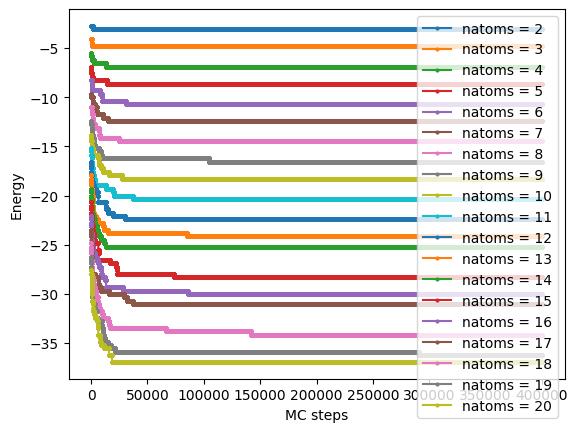

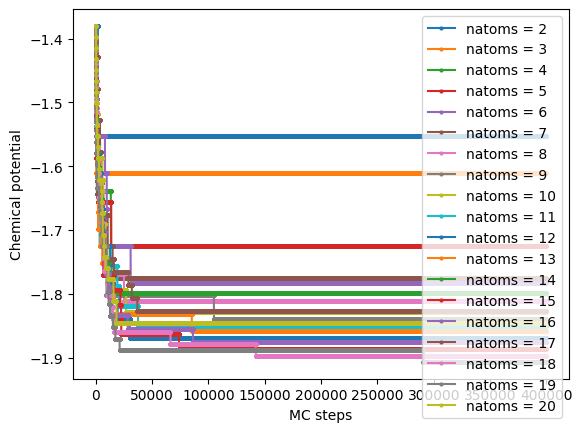

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

Temp = 0
natoms_list = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
MCsteps = 1000000
#myseed=16324478
#myseed = 42
#myseed = 0
#myseed = 1
#myseed = 2026
myseed = 1926


BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 3', 'natoms_list')
base_filename2 = "MMC_energy_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+").txt"

plt.figure()
for katoms in natoms_list:
    natoms = katoms
    base_filename = f"MMC_energy_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+").txt"
    filename = os.path.join(results_dir, base_filename)
    data = np.loadtxt(filename)
    steps = data[:,0]
    energy = data[:,1]
    chem_pot = energy / natoms


    plt.plot(steps[0:400000], energy[0:400000], 'o-', markersize=2, label=f"natoms = {str(natoms)}")
    plt.xlabel("MC steps")
    plt.ylabel("Energy")

plt.legend()
plt.show()


plt.figure()
for katoms in natoms_list:
    natoms = katoms
    base_filename = f"MMC_energy_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+").txt"
    filename = os.path.join(results_dir, base_filename)
    data = np.loadtxt(filename)
    steps = data[:,0]
    energy = data[:,1]
    chem_pot = energy / natoms


    plt.plot(steps[0:400000], chem_pot[0:400000], 'o-', markersize=2, label=f"natoms = {str(natoms)}")
    plt.xlabel("MC steps")
    plt.ylabel("Chemical potential")

plt.legend()
plt.show()



Plot punto 3 (energia media e potenziale chimico medio in funzione di natoms, per diversi seed sui cui si media)

>>> Caricamento dati per analisi Cluster...


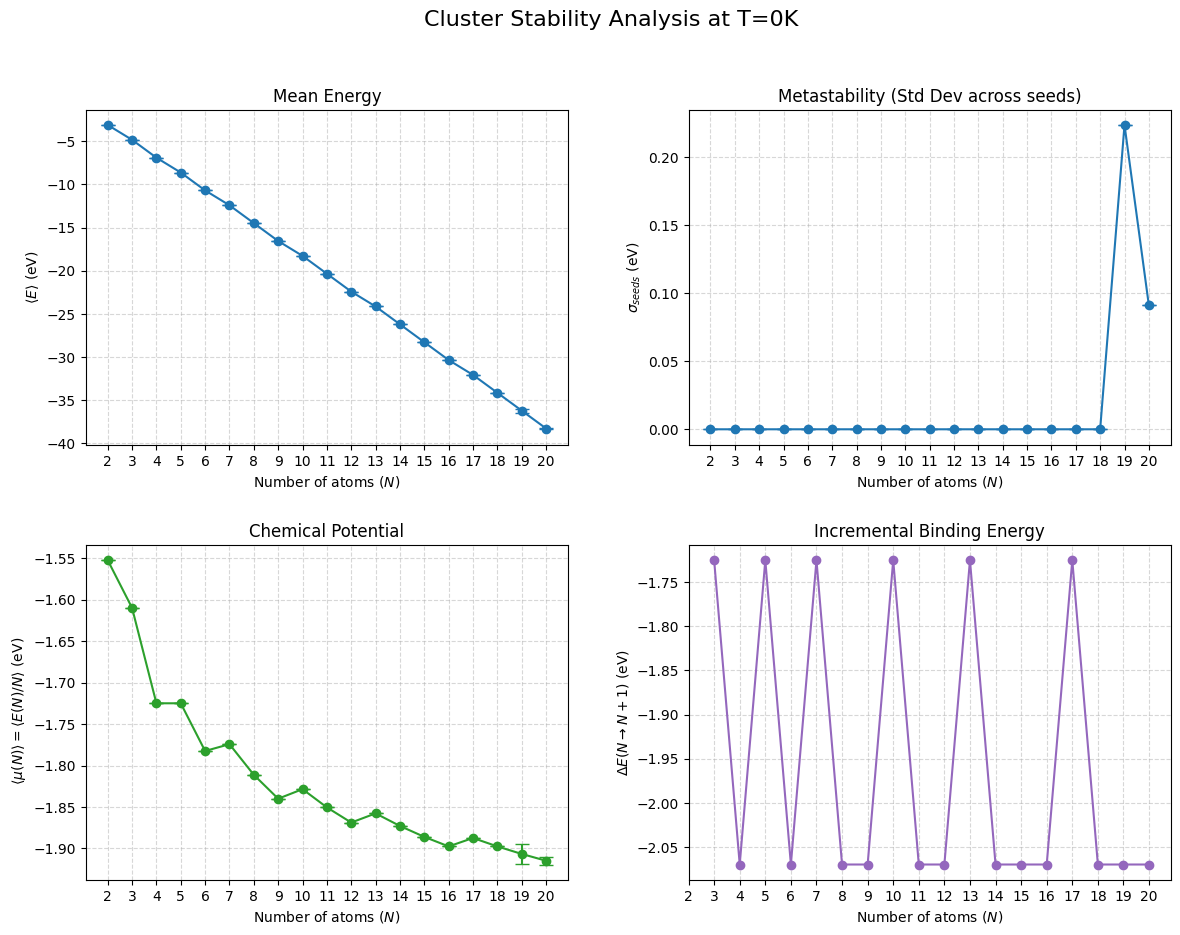

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Parametri ---
natoms_list = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
L = 60
#Seeds = [16324478, 42, 0, 1, 2026, 1926]
Seeds = [42]
MCsteps = 1000000
burn_in = 200000 
Temp = 0 # Assumo che i file siano salvati con "0K" nel nome

BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
# NOTA: Verifica che il percorso 'Punto 3' sia corretto per i file che hai generato
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 3', 'natoms_list')

# Liste per il plotting finale (X axis: natoms_list)
Y_E_mean, Y_E_err = [], []      # Energia Totale
Y_S_mean, Y_S_err = [], []      # Fluttuazioni (tra seed)
Y_Mu_mean, Y_Mu_err = [], []    # Energia per atomo (Chemical Pot / Cohesive Energy)
Y_Mu_fluc = []                  # Fluttuazione Mu
Y_seeds_err = []               

print(">>> Caricamento dati per analisi Cluster...")

for natoms in natoms_list:
    
    # Liste temporanee per i vari seed di QUESTO natoms
    seeds_E_final = []
    seeds_std_final = []
    
    for s in Seeds:
        base_filename = f"MMC_energy_{Temp}K_{natoms} atoms_{MCsteps} steps_seed({s}).txt"
        filename = os.path.join(results_dir, base_filename)
        
        if os.path.exists(filename):
            try:
                data = np.loadtxt(filename)
                energy = data[:, 1]
                # A T=0 prendiamo l'ultimo valore o la media della coda (dovrebbero essere identici)
                #en_last = np.mean(energy[burn_in:]) 
                en_last = energy[-1]
                std_last = np.std(energy[burn_in:])
                seeds_E_final.append(en_last)
                seeds_std_final.append(std_last)
            except:
                continue
    
    # Statistica sui seed per il natoms corrente
    if len(seeds_E_final) > 0:
        # Energia Totale
        avg_E = np.mean(seeds_E_final)
        std_E = np.mean(seeds_std_final) 
        std_seeds = np.std(seeds_E_final)
        
        Y_E_mean.append(avg_E)
        Y_E_err.append(std_E)
        Y_seeds_err.append(std_seeds)
        
        # Energia per atomo (spesso chiamata binding energy o potenziale chimico medio)
        # Mu = E_tot / N
        avg_Mu = avg_E / natoms
        std_Mu = std_E / natoms
        
        Y_Mu_mean.append(avg_Mu)
        Y_Mu_err.append(std_Mu)
        
        # Qui potremmo mettere la deviazione standard temporale, ma a T=0 è 0.
        # Usiamo lo std tra seed come misura di "incertezza" dello stato fondamentale
        Y_S_mean.append(std_E) 
        
    else:
        print(f"Attenzione: Nessun dato trovato per natoms = {natoms}")
        Y_E_mean.append(np.nan)
        Y_E_err.append(np.nan)
        Y_Mu_mean.append(np.nan)
        Y_Mu_err.append(np.nan)
        Y_S_mean.append(np.nan)

# --- PLOTTING ---

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# 1. Energia Totale Media vs N
# Questo grafico deve scendere linearmente (più atomi = più energia negativa)
axs[0, 0].errorbar(natoms_list, Y_E_mean, yerr=Y_E_err, fmt='-o', capsize=5, color='tab:blue')
axs[0, 0].set_ylabel(r"$\langle E \rangle$ (eV)")
axs[0, 0].set_title("Mean Energy")

# 2. Incertezza (Std Dev tra Seeds)
# Se questo grafico ha picchi, significa che per quel N ci sono isomeri stabili diversi
#axs[0, 1].plot(natoms_list, Y_E_err, '-o', color='tab:red')
axs[0, 1].errorbar(natoms_list, Y_E_err, yerr=Y_seeds_err, fmt='-o', capsize=5, color='tab:blue')
axs[0, 1].set_ylabel(r"$\sigma_{seeds}$ (eV)")
axs[0, 1].set_title("Metastability (Std Dev across seeds)")

# 3. Energia per Atomo (Cohesive Energy) vs N
# Questo grafico tende a un asintoto per N grandi (energia di coesione del bulk)
axs[1, 0].errorbar(natoms_list, Y_Mu_mean, yerr=Y_Mu_err, fmt='-o', capsize=5, color='tab:green')
axs[1, 0].set_ylabel(r" $\langle \mu(N)\rangle = \langle E(N)/N \rangle$ (eV)")
axs[1, 0].set_title("Chemical Potential")

# 4. Energia di Legame Incrementale (Opzionale ma molto fisica)
# Delta E = E(N) - E(N-1). Approssimazione discreta del potenziale chimico reale.
# Calcoliamo la derivata discreta
dE = np.diff(Y_E_mean)
dN = np.array(natoms_list[1:]) 
axs[1, 1].plot(dN, dE, '-o', color='tab:purple')
axs[1, 1].set_ylabel(r"$\Delta E (N \to N+1)$ (eV)")
axs[1, 1].set_title("Incremental Binding Energy")
# Se preferisci plottare sigma_mu come richiesto prima, scommenta sotto e commenta sopra:
# axs[1, 1].plot(natoms_list, Y_Mu_err, '-o', color='tab:purple')
# axs[1, 1].set_ylabel(r"$\sigma_\mu$ across seeds")

for ax in axs.flat:
    ax.set_xlabel("Number of atoms ($N$)")
    ax.grid(True, linestyle='--', alpha=0.5)
    # Impostiamo i ticks dell'asse X per mostrare solo interi
    ax.set_xticks(natoms_list)

plt.suptitle(f"Cluster Stability Analysis at T={Temp}K", fontsize=16)
plt.show()

Plot punto 3 senza mediare tra i seed

Energia media e potenziale chimico medio, con relative deviazioni stazndard, in funzione di natoms

Elaborazione Seed 16324478...
Elaborazione Seed 42...
Elaborazione Seed 0...
Elaborazione Seed 1...
Elaborazione Seed 2026...
Elaborazione Seed 1926...


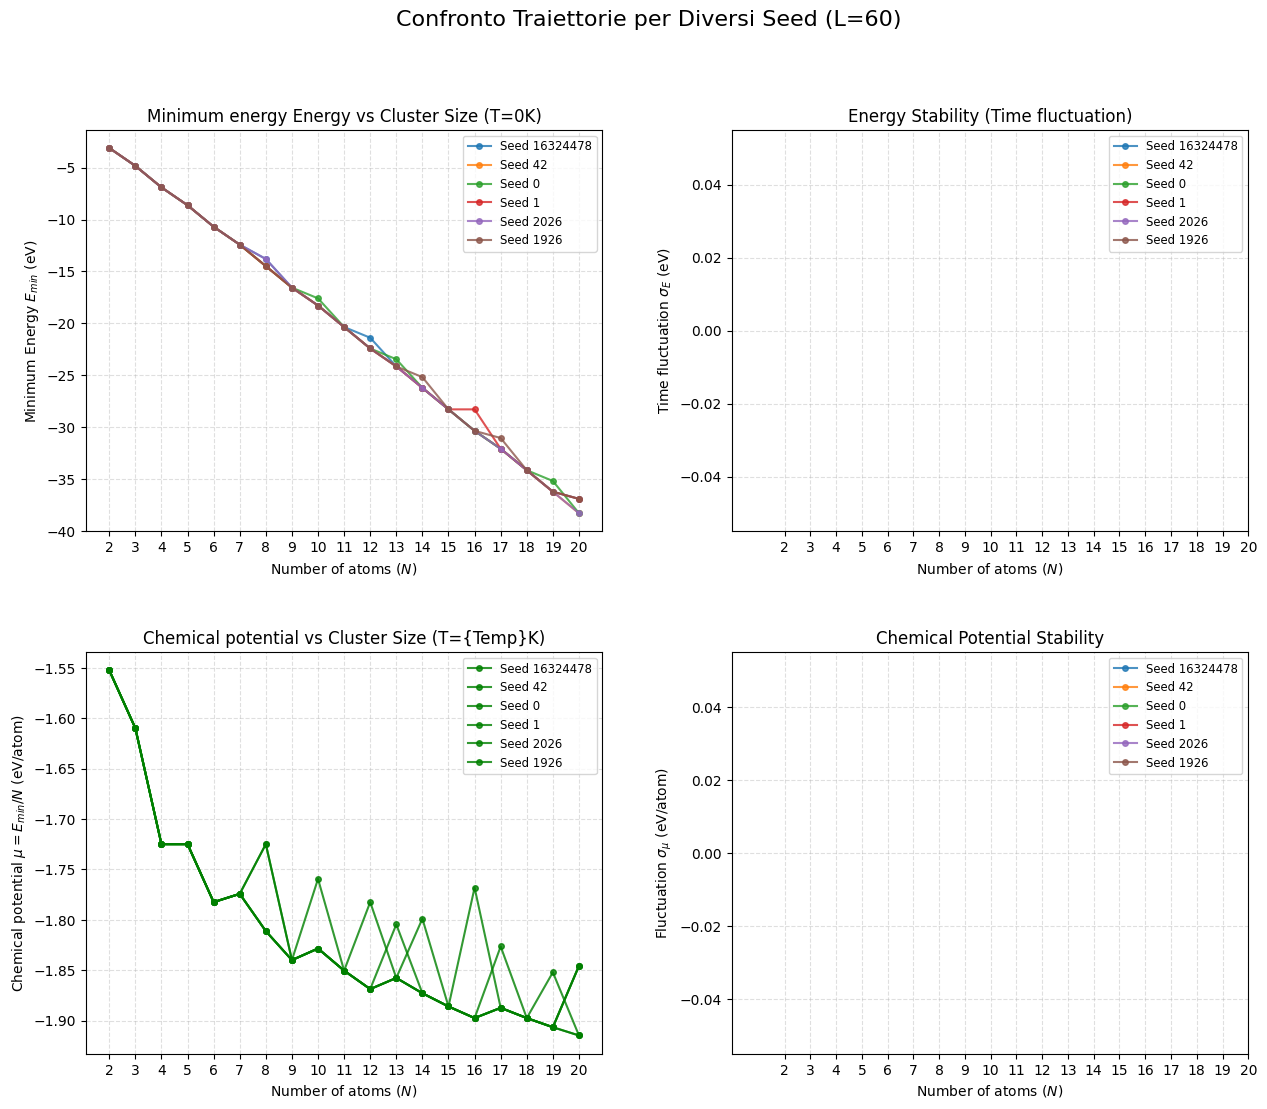

In [139]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Parametri ---
natoms_list = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
L = 60
Seeds = [16324478, 42, 0, 1, 2026, 1926]
#Seeds = [42]
MCsteps = 1000000
burn_in = 200000 
Temp = 0 # Assumo T=0 (Minimize)

BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
# Verifica che il percorso sia corretto
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 3', 'natoms_list')

# Creazione della figura
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Iteriamo su ogni seed per plottare la sua "storia" indipendentemente
for s in Seeds:
    print(f"Elaborazione Seed {s}...")
    
    # Liste per questo specifico seed
    Y_E = []        # Energia Totale
    Y_SigmaE = []   # Fluttuazione Energia (temporale)
    Y_Mu = []       # Potenziale Chimico (E/N)
    Y_SigmaMu = []  # Fluttuazione Mu (temporale)
    
    # Per ogni seed, raccogliamo i dati al variare di N atomi
    for natoms in natoms_list:
        base_filename = f"MMC_energy_{Temp}K_{natoms} atoms_{MCsteps} steps_seed({s}).txt"
        filename = os.path.join(results_dir, base_filename)
        
        val_E = np.nan
        val_S = np.nan
        
        if os.path.exists(filename):
            try:
                data = np.loadtxt(filename)
                energy = data[:, 1]
                
                # Prendiamo la parte equilibrata
                en_eq = energy[burn_in:]
                
                val_E = en_eq[-1]
                #val_E = np.mean(en_eq)
                #val_S = np.std(en_eq)
            except:
                pass # Lascia NaN
        
        # Salviamo i dati nelle liste
        Y_E.append(val_E)
        Y_SigmaE.append(val_S)
        
        # Calcolo grandezze intensive (per atomo)
        if not np.isnan(val_E):
            Y_Mu.append(val_E / natoms)
            Y_SigmaMu.append(val_S / natoms)
        else:
            Y_Mu.append(np.nan)
            Y_SigmaMu.append(np.nan)

    # --- PLOTTING PER QUESTO SEED ---
    # Usiamo un marker leggero per vedere i punti sovrapposti
    axs[0, 0].plot(natoms_list, Y_E, '-o', label=f'Seed {s}', markersize=4, alpha=0.8)
    axs[0, 1].plot(natoms_list, Y_SigmaE, '-o', label=f'Seed {s}', markersize=4, alpha=0.8)
    axs[1, 0].plot(natoms_list, Y_Mu, '-o',color='g', label=f'Seed {s}', markersize=4, alpha=0.8)
    axs[1, 1].plot(natoms_list, Y_SigmaMu, '-o', label=f'Seed {s}', markersize=4, alpha=0.8)

# --- FORMATTAZIONE GRAFICI ---

# 1. Energia Totale
axs[0, 0].set_ylabel(r"Minimum Energy $E_{min}$ (eV)")
axs[0, 0].set_title(f"Minimum energy Energy vs Cluster Size (T={Temp}K)")

# 2. Fluttuazioni Temporali (Dovrebbero essere 0 a T=0)
axs[0, 1].set_ylabel(r"Time fluctuation $\sigma_E$ (eV)")
axs[0, 1].set_title("Energy Stability (Time fluctuation)")

# 3. Potenziale Chimico (Energia per atomo)
axs[1, 0].set_ylabel(r"Chemical potential $ \mu = E_{min} /N$ (eV/atom)")
axs[1, 0].set_title("Chemical potential vs Cluster Size (T={Temp}K)")

# 4. Fluttuazione Potenziale Chimico
axs[1, 1].set_ylabel(r"Fluctuation $\sigma_\mu$ (eV/atom)")
axs[1, 1].set_title("Chemical Potential Stability")

for ax in axs.flat:
    ax.set_xlabel("Number of atoms ($N$)")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xticks(natoms_list) # Forza gli interi sull'asse X
    ax.legend(fontsize='small')

plt.suptitle(f"Confronto Traiettorie per Diversi Seed (L={L})", fontsize=16)
plt.show()

Elaborazione Seed 16324478...
Elaborazione Seed 42...
Elaborazione Seed 0...
Elaborazione Seed 1...
Elaborazione Seed 2026...
Elaborazione Seed 1926...


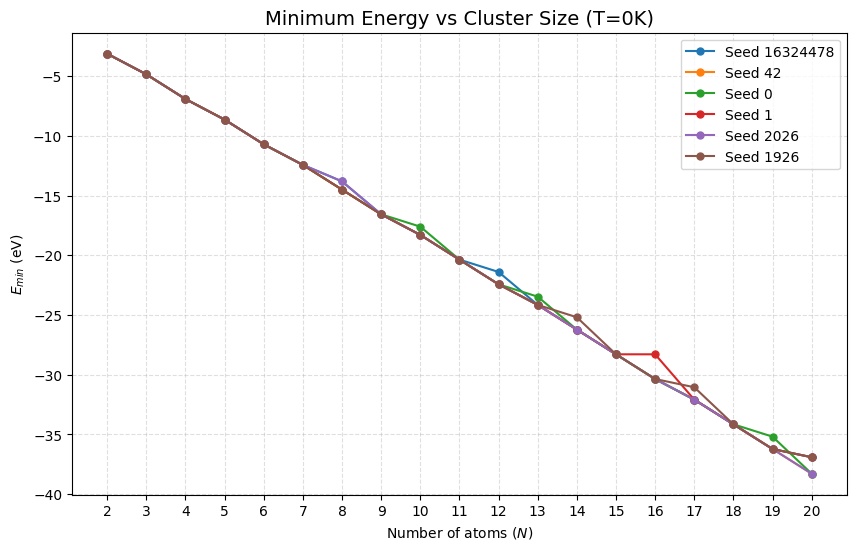

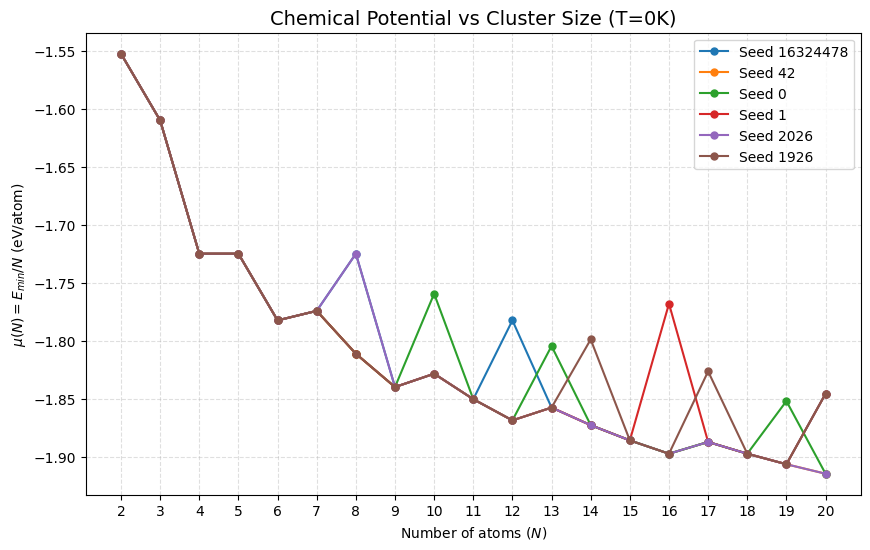

In [141]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Parametri ---
natoms_list = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
L = 60
Seeds = [16324478, 42, 0, 1, 2026, 1926]
#Seeds = [42]
MCsteps = 1000000
burn_in = 150000 
Temp = 0 

BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 3', 'natoms_list')

# Dizionario per memorizzare i dati di ogni seed
results = {s: {'Y_E': [], 'Y_Mu': []} for s in Seeds}

# --- Estrazione Dati ---
for s in Seeds:
    print(f"Elaborazione Seed {s}...")
    
    for natoms in natoms_list:
        base_filename = f"MMC_energy_{Temp}K_{natoms} atoms_{MCsteps} steps_seed({s}).txt"
        filename = os.path.join(results_dir, base_filename)
        
        val_E = np.nan
        
        if os.path.exists(filename):
            try:
                data = np.loadtxt(filename)
                energy = data[:, 1]
                en_eq = energy[burn_in:]
                
                # Prendiamo l'ultimo valore per l'energia minima
                val_E = en_eq[-1]
            except:
                pass 
        
        results[s]['Y_E'].append(val_E)
        if not np.isnan(val_E):
            results[s]['Y_Mu'].append(val_E / natoms)
        else:
            results[s]['Y_Mu'].append(np.nan)

# --- GRAFICO 1: Energia Minima ---
plt.figure(figsize=(10, 6))
for s in Seeds:
    plt.plot(natoms_list, results[s]['Y_E'], '-o', label=f'Seed {s}', markersize=5)

plt.title(f"Minimum Energy vs Cluster Size (T={Temp}K)", fontsize=14)
plt.xlabel("Number of atoms ($N$)")
plt.ylabel(r"$E_{min}$ (eV)")
plt.xticks(natoms_list)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

# --- GRAFICO 2: Potenziale Chimico ---
plt.figure(figsize=(10, 6))
for s in Seeds:
    plt.plot(natoms_list, results[s]['Y_Mu'], '-o',label=f'Seed {s}', markersize=5)

plt.title(f"Chemical Potential vs Cluster Size (T={Temp}K)", fontsize=14)
plt.xlabel("Number of atoms ($N$)")
plt.ylabel(r"$\mu (N) = E_{min} / N$ (eV/atom)")
plt.xticks(natoms_list)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

Energia media e deviazione std, potenziale chimico ed energia legame (E(N)-E(N-1)), in funzione di natoms

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Parametri ---
natoms_list = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
L = 60
Seeds = [16324478, 42, 0, 1, 2026, 1926]
MCsteps = 1000000
burn_in = 150000 
Temp = 0 

BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 3', 'natoms_list')

# Prepariamo la figura 2x2
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

print(">>> Elaborazione dei singoli Seed...")

# Iteriamo su ogni seed per creare una curva dedicata in ogni grafico
for s in Seeds:
    s_E_means = []
    s_E_stds = []
    s_Mu = []
    
    # Raccogliamo i dati per questo seed al variare di N
    for natoms in natoms_list:
        base_filename = f"MMC_energy_{Temp}K_{natoms} atoms_{MCsteps} steps_seed({s}).txt"
        filename = os.path.join(results_dir, base_filename)
        
        if os.path.exists(filename):
            try:
                data = np.loadtxt(filename)
                energy = data[:, 1]
                en_eq = energy[burn_in:]
                
                m_en = np.mean(en_eq)
                s_en = np.std(en_eq)
                
                s_E_means.append(m_en)
                s_E_stds.append(s_en)
                s_Mu.append(m_en / natoms)
            except:
                s_E_means.append(np.nan)
                s_E_stds.append(np.nan)
                s_Mu.append(np.nan)
        else:
            s_E_means.append(np.nan)
            s_E_stds.append(np.nan)
            s_Mu.append(np.nan)

    # Convertiamo in array per calcoli vettoriali
    s_E_means = np.array(s_E_means)
    
    # 1. Grafico Energia Totale
    axs[0, 0].plot(natoms_list, s_E_means, '-o', label=f'Seed {s}', markersize=4, alpha=0.7)
    
    # 2. Grafico Deviazione Standard (Fluttuazione interna al seed)
    axs[0, 1].plot(natoms_list, s_E_stds, '-o', label=f'Seed {s}', markersize=4, alpha=0.7)
    
    # 3. Grafico Potenziale Chimico (Energia Coesiva E/N)
    axs[1, 0].plot(natoms_list, s_Mu, '-o', label=f'Seed {s}', markersize=4, alpha=0.7)
    
    # 4. Grafico Energia di Legame Incrementale (Delta E = E_N - E_{N-1})
    # Usiamo np.diff per calcolare la differenza tra elementi adiacenti
    delta_E = np.diff(s_E_means)
    # L'asse X per Delta E parte dal secondo atomo della lista
    axs[1, 1].plot(natoms_list[1:], delta_E, '-o', label=f'Seed {s}', markersize=4, alpha=0.7)

# --- Formattazione Finale ---

# Titoli e Label
axs[0, 0].set_title("Total Energy $E$", fontsize=14)
axs[0, 0].set_ylabel("Energy (eV)")

axs[0, 1].set_title("Energy Std Dev $\sigma_E$ (Simulation)", fontsize=14)
axs[0, 1].set_ylabel("$\sigma_E$ (eV)")

axs[1, 0].set_title("Chemical Potential $\mu = E/N$", fontsize=14)
axs[1, 0].set_ylabel("Energy per atom (eV/at)")

axs[1, 1].set_title("Incremental Binding Energy $\Delta E$", fontsize=14)
axs[1, 1].set_ylabel("$E(N) - E(N-1)$ (eV)")

for ax in axs.flat:
    ax.set_xlabel("Number of atoms ($N$)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks(natoms_list)
    ax.legend(fontsize='x-small', ncol=2)

plt.suptitle(f"Analisi di Stabilità dei Cluster (T={Temp}K) - Confronto tra Seed", fontsize=16)
plt.show()

Punto 4

Ciclo sulle temperature

In [81]:
import numpy as np
import matplotlib.pyplot as plt 
import os
import time
from numba import jit
from MMC_codes import energy, printXYZ, neighXYZ, pbcCorr
#folder
BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 4', 'Temp_list_new')
#os.makedirs(results_dir1, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

#input and parameters
#myseed = 16324478
myseed = 42
#myseed = 0
#myseed = 1
#myseed = 2026
#myseed = 1926
#myseed = 1492

np.random.seed(myseed)
k_B = 1 / 11603
Lx = 20     
Ly = 20 
L = 20
#Temp_list = [1, 2, 10, 50, 100, 150, 200, 400, 650, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 1550, 1600, 1650, 1700, 1750, 1800, 1900, 2000, 2100, 2300, 2500, 2700]
#Temp_list = [1150, 1250, 1350, 1550, 1650, 1750]
Temp_list = [1,2]
nu = 1e13
J1 = -0.345
J0 = 4 * J1
natoms = 25
MCsteps = 1000000

for ktemp in Temp_list:
    Temp = ktemp

    #initializations
    height = np.zeros((Lx,Ly),int) 
    istep = 0

    #initial configuration
    for iatoms in range(0,natoms):
        xin = np.random.randint(Lx)
        yin = np.random.randint(Lx)
        height[xin,yin] +=1
    
    print(f"Seed: ", myseed)
    print(f"Temperature: ", Temp)
    print(f"natoms (sum(height)): ", np.sum(height)) #this should return natoms
    print(f"Dimension of the lattice L = ",L)
    Eold = energy(height,Lx,Ly,J0,J1) #this should return a value around natoms*J0
    print(f"Initial energy E = ", Eold)
    print("natoms*J0: ", natoms*J0)
    print("Initial energy - natoms*J0: ", Eold - natoms*J0)

    
    base_filename2 = "MMC_energy_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+")_L"+str(L)+".txt"
    outputname2 = os.path.join(results_dir, base_filename2)
    fout = open(outputname2 , 'w')
    for istep in range(MCsteps):

        listAt = np.argwhere(height>0) 
        idxAt = np.random.randint(len(listAt)) 
        xold,yold = listAt[idxAt]
        height[xold,yold] -= 1

        xnew = np.random.randint(Lx)
        ynew = np.random.randint(Ly)
        height[xnew,ynew] += 1

        Enew = energy(height,Lx,Ly,J0,J1)

        #the new configuration becomes the current state
        if (Enew-Eold) < 1e-8: #the inimum difference is one bond (0.34 (?)) so we're safe
            Eold = Enew
            
        elif np.random.rand() < np.exp(-(Enew-Eold)/(k_B*Temp)): #importance sampling
            Eold = Enew

        else: #restore previous configuration
            height[xold,yold] += 1
            height[xnew,ynew] -= 1

        #Output (when needed)
        '''if (istep % 10000 == 0):
            base_filename1 = "MMC_xyz_"+str(Temp)+"K_"+str(natoms)+" atoms_"+str(MCsteps)+" steps_seed("+str(myseed)+") (step "+str(istep)+")_L"+str(L)+".txt"
            outputname1 = os.path.join(results_dir, base_filename1)
            printXYZ(outputname1, height, Lx, Ly)
            print(Eold)'''
            
        #the 0K loop will just go to the minimum, so it's enough to print only the last step
        fout.write(f"{istep} {Eold} \n")

        istep += 1
        

    print(f'Final configuration: Efinal = ', Eold)
    printXYZ(outputname1,height,Lx,Ly)
    fout.close()


print("Simulation completed")

Seed:  42
Temperature:  1
natoms (sum(height)):  25
Dimension of the lattice L =  20
Initial energy E =  -35.18999999999999
natoms*J0:  -34.5
Initial energy - natoms*J0:  -0.6899999999999906
Final configuration: Efinal =  -48.30000000000001
Seed:  42
Temperature:  2
natoms (sum(height)):  25
Dimension of the lattice L =  20
Initial energy E =  -34.499999999999986
natoms*J0:  -34.5
Initial energy - natoms*J0:  1.4210854715202004e-14
Final configuration: Efinal =  -48.30000000000001
Simulation completed


Plot punto 4

Plot per diversi L, T, seed

<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\s'
<>:137: SyntaxWarning: invalid escape sequence '\s'
<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\s'
<>:137: SyntaxWarning: invalid escape sequence '\s'
/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_17363/2539551048.py:72: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Energy Fluctuations $\sigma_E$")
/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_17363/2539551048.py:84: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Mean Chemical Potential <$\mu$>")
/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_17363/2539551048.py:98: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Chemical Potential Fluctuations $\sigma_\mu$")
/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykern

>>> Elaborazione dati in corso...


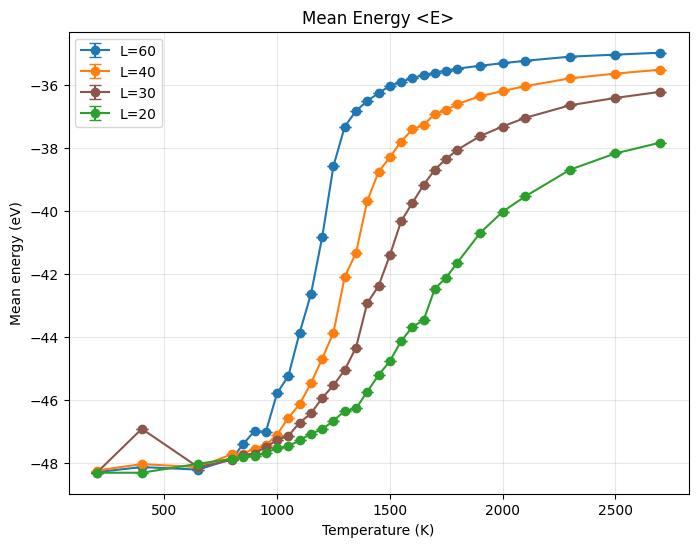

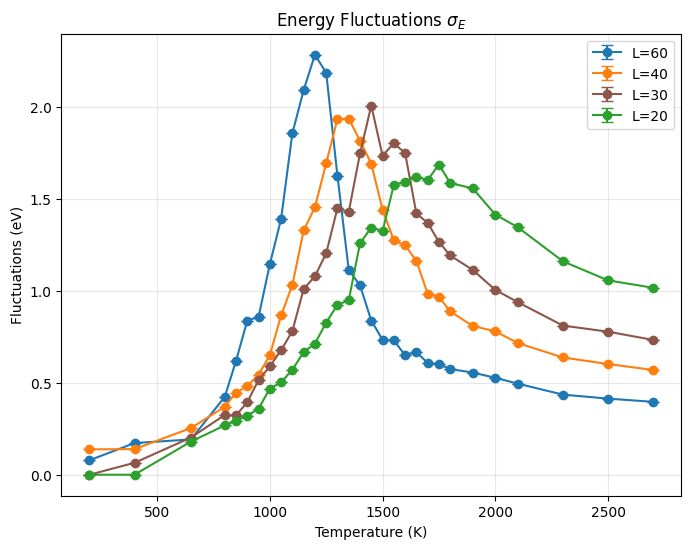

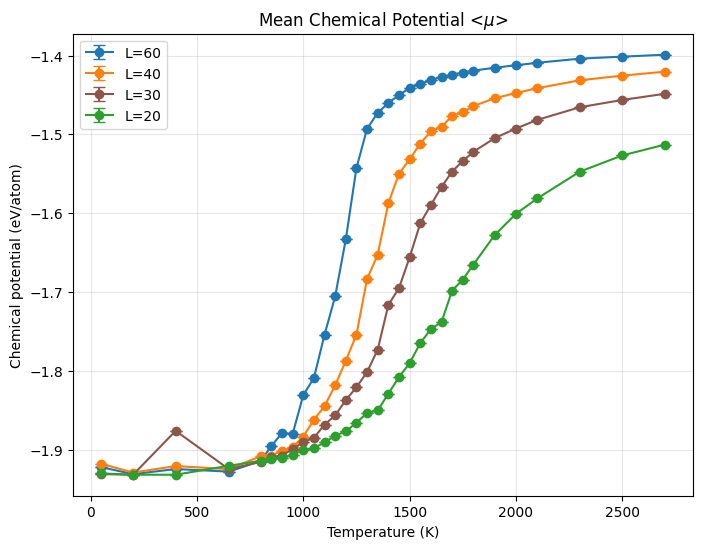

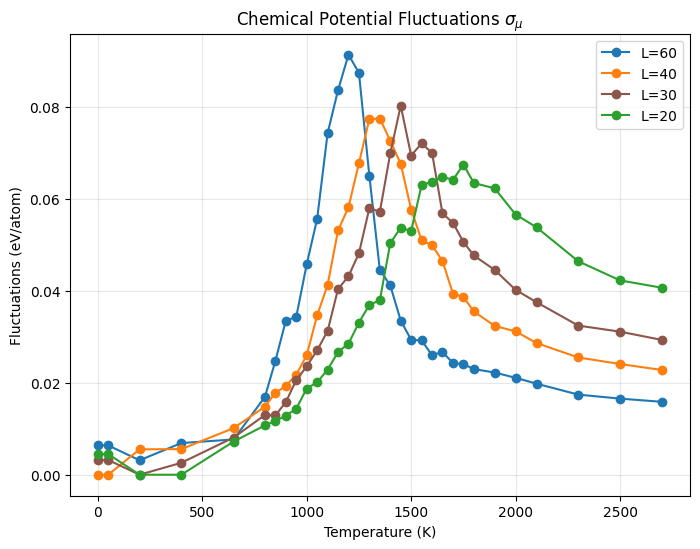

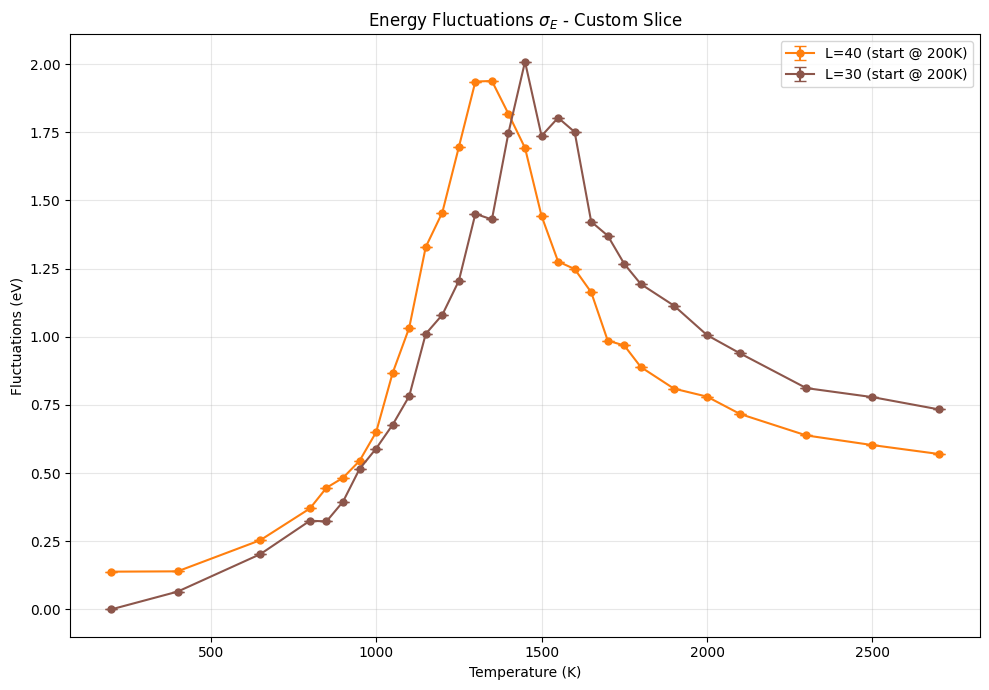

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Parametri ---
Temp_list = [1, 2, 50, 200, 400, 650, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 1550, 1600, 1650, 1700, 1750, 1800, 1900, 2000, 2100, 2300, 2500, 2700]
L_list = [60, 40, 30, 20]
#Seeds = [16324478, 42, 0, 1, 2026, 1926]
Seeds = [42]
MCsteps = 1000000
natoms = 25
burn_in = 300000 

BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 4', 'Temp_list_new')

# Struttura dati
final_stats = {L: {key: [] for key in ['E_avg', 'E_err', 'S_avg', 'S_err', 'M_avg', 'M_err']} for L in L_list}

print(">>> Elaborazione dati in corso...")

for L in L_list:
    for Temp in Temp_list:
        seeds_Emean, seeds_Estd, seeds_Mumean = [], [], []

        for s in Seeds:
            base_filename = f"MMC_energy_{Temp}K_{natoms} atoms_{MCsteps} steps_seed({s})_L{L}.txt"
            filename = os.path.join(results_dir, base_filename)
            
            try:
                data = np.loadtxt(filename)
                energy = data[:, 1]
                en_eq = energy[burn_in:]
                
                seeds_Emean.append(np.mean(en_eq))
                seeds_Estd.append(np.std(en_eq))
                seeds_Mumean.append(np.mean(en_eq) / natoms)
            except OSError:
                continue 

        if seeds_Emean:
            final_stats[L]['E_avg'].append(np.mean(seeds_Emean))
            final_stats[L]['E_err'].append(np.std(seeds_Emean))
            final_stats[L]['S_avg'].append(np.mean(seeds_Estd))
            final_stats[L]['S_err'].append(np.std(seeds_Estd))
            final_stats[L]['M_avg'].append(np.mean(seeds_Mumean))
            final_stats[L]['M_err'].append(np.std(seeds_Mumean))
        else:
            for key in final_stats[L]: final_stats[L][key].append(np.nan)

# --- PLOTTING (Grafici separati) ---

colors = {60: 'tab:blue', 40: 'tab:orange', 30:'tab:brown', 20: 'tab:green'}

# 1. Energia Media
plt.figure(figsize=(8, 6))
for L in L_list:
    plt.errorbar(Temp_list[3:], final_stats[L]['E_avg'][3:], yerr=final_stats[L]['E_err'][3:], 
                 fmt='o-', label=f'L={L}', capsize=4, color=colors[L])
plt.title("Mean Energy <E>")
plt.xlabel("Temperature (K)")
plt.ylabel("Mean energy (eV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Fluttuazioni Energia
plt.figure(figsize=(8, 6))
for L in L_list:
    plt.errorbar(Temp_list[3:], final_stats[L]['S_avg'][3:], yerr=final_stats[L]['S_err'][3:], 
                 fmt='o-', label=f'L={L}', capsize=4, color=colors[L])
plt.title("Energy Fluctuations $\sigma_E$")
plt.xlabel("Temperature (K)")
plt.ylabel("Fluctuations (eV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Potenziale Chimico
plt.figure(figsize=(8, 6))
for L in L_list:
    plt.errorbar(Temp_list[2:], final_stats[L]['M_avg'][2:], yerr=final_stats[L]['M_err'][2:], 
                 fmt='o-', label=f'L={L}', capsize=4, color=colors[L])
plt.title("Mean Chemical Potential <$\mu$>")
plt.xlabel("Temperature (K)")
plt.ylabel("Chemical potential (eV/atom)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Fluttuazioni Potenziale Chimico
plt.figure(figsize=(8, 6))
for L in L_list:
    s_mu_avg = np.array(final_stats[L]['S_avg']) / natoms
    # Nota: qui plottiamo solo la media delle sigma_mu per chiarezza, 
    # ma potresti aggiungere yerr=np.array(final_stats[L]['S_err'])/natoms
    plt.plot(Temp_list[1:], s_mu_avg[1:], 'o-', label=f'L={L}', color=colors[L])
plt.title("Chemical Potential Fluctuations $\sigma_\mu$")
plt.xlabel("Temperature (K)")
plt.ylabel("Fluctuations (eV/atom)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# --- NUOVA SEZIONE: GRAFICO DELLE FLUTTUAZIONI PERSONALIZZABILE ---

# 1. Configurazione: decidi qui quanti punti saltare per ogni L.
# L'indice 0 corrisponde a 1K, l'indice 3 a 50K, ecc.
# Modifica i numeri nel dizionario qui sotto a tuo piacimento.
custom_skip = {
    60: 3,  # Valore standard (salta 1K, 2K, 10K)
    40: 3,
    30: 3,
    20: 3
}

# ESEMPIO: Se per L=60 vuoi tagliare altri 3 punti oltre ai primi 3 (totale 6):
# custom_skip[60] = 6 

plt.figure(figsize=(10, 7))

for L in [40, 30]:
    # Recuperiamo l'indice di partenza per questo specifico L
    start_idx = custom_skip.get(L, 0)
    
    # Selezioniamo i dati in base all'indice
    t_plot = Temp_list[start_idx:]
    s_plot = final_stats[L]['S_avg'][start_idx:]
    s_err_plot = final_stats[L]['S_err'][start_idx:]
    
    # Plot con barre d'errore
    plt.errorbar(t_plot, s_plot, yerr=s_err_plot, 
                 fmt='o-', label=f'L={L} (start @ {Temp_list[start_idx]}K)', 
                 capsize=4, color=colors[L], markersize=5)

plt.title("Energy Fluctuations $\sigma_E$ - Custom Slice")
plt.xlabel("Temperature (K)")
plt.ylabel("Fluctuations (eV)")
plt.legend()
plt.grid(True, alpha=0.3)

# Opzionale: aggiungi una linea verticale per evidenziare una zona di interesse
# plt.axvline(x=1000, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Energy as a function of MC steps

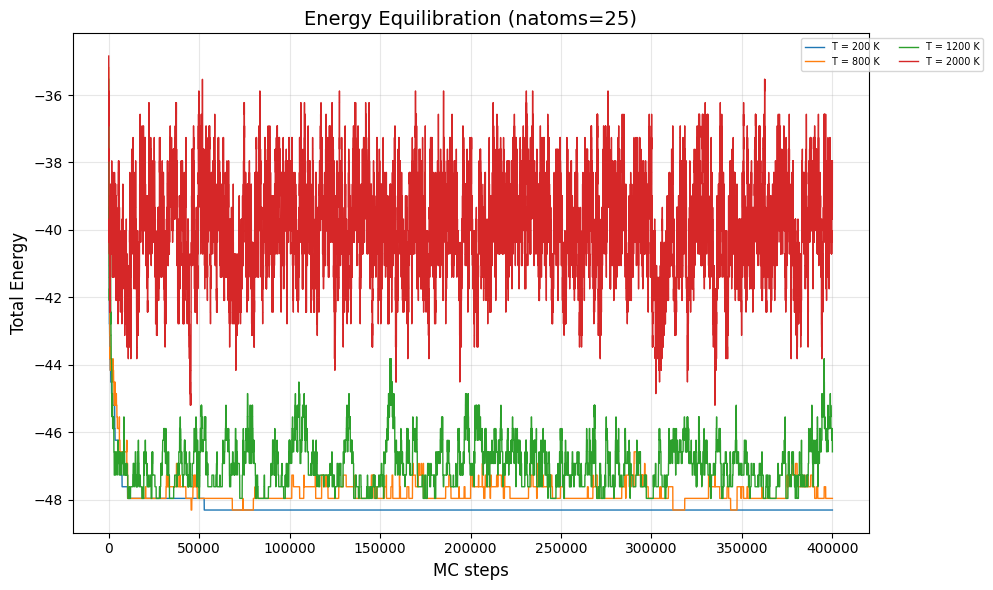

/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_5913/2116497241.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize='x-small', ncol=2)


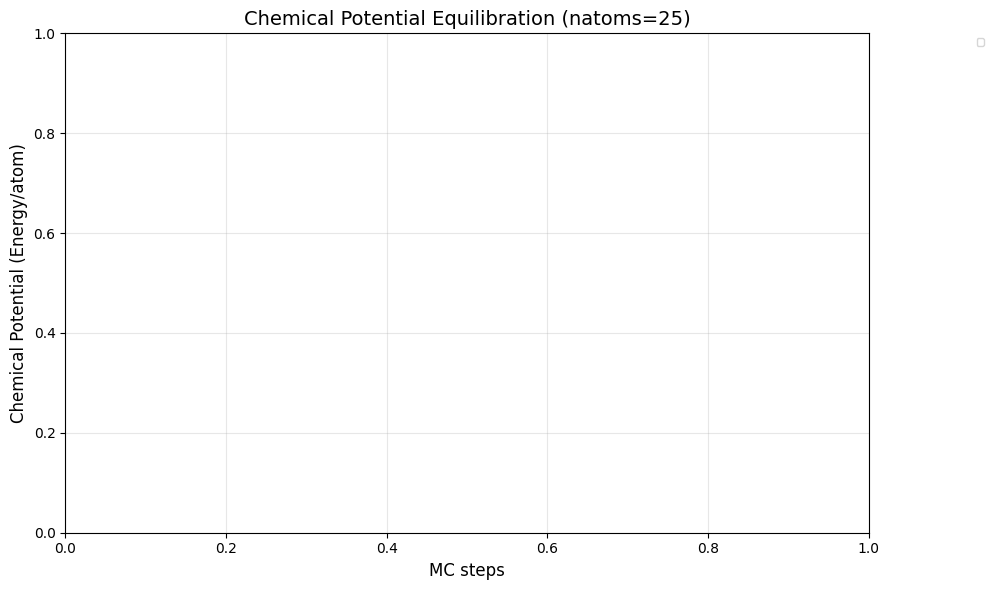

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. DEFINIZIONE DEI PARAMETRI ---
# Fissiamo il numero di atomi come richiesto
natoms = 25 
MCsteps = 1000000

# Selezioniamo un seed (decommenta quello corretto usato nelle tue simulazioni)
myseed = 16324478 
# myseed = 42

# Lista delle temperature su cui iterare
Temp_list = [200, 800, 1200, 2000]

# --- 2. GESTIONE DEI PERCORSI ---
# Nota: Assicurati che 'MS_coding_MMC_1.ipynb' esista o modifica BASE_PATH manualmente
try:
    BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_MMC_1.ipynb'))
except:
    BASE_PATH = "." # Fallback alla cartella corrente se non trova il riferimento
    
results_dir = os.path.join(BASE_PATH, 'Esercizio 2', 'Punto 4', 'Temp_list_new')

# --- 3. PLOT ENERGIA vs MC STEPS ---
plt.figure(figsize=(10, 6)) # Ingrandisco la figura per chiarezza

for Temp in Temp_list:
    # Costruiamo il nome del file variando la Temperatura (Temp)
    base_filename = f"MMC_energy_{Temp}K_{natoms} atoms_{MCsteps} steps_seed({s})_L{L}.txt"
    filename = os.path.join(results_dir, base_filename)
    
    # Controllo di sicurezza: processa solo se il file esiste
    if os.path.exists(filename):
        data = np.loadtxt(filename)
        steps = data[:,0]
        energy = data[:,1]
        
        # Plotto i primi 400k step.
        # Nota: riduco markersize e uso linee sottili per leggibilità dato l'alto numero di curve
        plt.plot(steps[0:400000], energy[0:400000], '-', linewidth=1, label=f"T = {Temp} K")
    else:
        print(f"Warning: File non trovato per T = {Temp} K")

plt.xlabel("MC steps", fontsize=12)
plt.ylabel("Total Energy", fontsize=12)
plt.title(f"Energy Equilibration (natoms={natoms})", fontsize=14)
# La legenda potrebbe essere molto lunga, la posiziono fuori o la rimpicciolisco
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize='x-small', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout() # Aggiusta i margini
plt.show()


# --- 4. PLOT POTENZIALE CHIMICO vs MC STEPS ---
plt.figure(figsize=(10, 6))

for Temp in Temp_list:
    base_filename = f"MMC_energy_{Temp}K_{natoms} atoms_{MCsteps} steps_seed({myseed}).txt"
    filename = os.path.join(results_dir, base_filename)
    
    if os.path.exists(filename):
        data = np.loadtxt(filename)
        steps = data[:,0]
        energy = data[:,1]
        chem_pot = energy / natoms # Calcolo potenziale chimico
        
        plt.plot(steps[0:400000], chem_pot[0:400000], '-', linewidth=1, label=f"T = {Temp} K")

plt.xlabel("MC steps", fontsize=12)
plt.ylabel("Chemical Potential (Energy/atom)", fontsize=12)
plt.title(f"Chemical Potential Equilibration (natoms={natoms})", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize='x-small', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()